# CIFAR-10 Image Classification with Custom CNN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

# Set device for training (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## TASK **1**

We will load the CIFAR-10 dataset and filter it to include only the 'airplane', 'automobile', and 'ship' classes. A custom transformation is applied to normalize the images.

In [ ]:
# Define transformations for the dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize pixel values to [-1, 1]
])

# Load CIFAR-10 training and test datasets
train_dataset_full = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset_full = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Define the target classes and their original indices in CIFAR-10
target_classes = ['airplane', 'automobile', 'ship']
cifar10_classes = train_dataset_full.classes

# Get original indices of target classes
target_indices = [cifar10_classes.index(cls) for cls in target_classes]
print(f"Target classes: {target_classes}")
print(f"Corresponding CIFAR-10 indices: {target_indices}")

# Create a mapping from original CIFAR-10 indices to new 0, 1, 2 indices
# This is important for the CrossEntropyLoss function which expects target labels from 0 to C-1
index_mapping = {original_idx: new_idx for new_idx, original_idx in enumerate(target_indices)}
print(f"Index mapping (Original CIFAR-10 index -> New 0-2 index): {index_mapping}")


def filter_and_map_dataset(dataset, target_indices, index_mapping):
    """Filters the dataset for target classes and maps their labels."""
    indices_to_keep = [i for i, label in enumerate(dataset.targets) if label in target_indices]
    filtered_dataset = Subset(dataset, indices_to_keep)

    # Modify the targets in the filtered dataset to be 0, 1, 2
    original_targets = np.array(dataset.targets)[indices_to_keep]
    new_targets = [index_mapping[t] for t in original_targets]

    class CustomFilteredDataset(torch.utils.data.Dataset):
        def __init__(self, original_subset, new_labels):
            self.original_subset = original_subset
            self.new_labels = new_labels

        def __len__(self):
            return len(self.original_subset)

        def __getitem__(self, idx):
            image, _ = self.original_subset[idx]
            label = self.new_labels[idx]
            return image, label

    return CustomFilteredDataset(filtered_dataset, new_targets)

# Filter and map training and test datasets
train_dataset = filter_and_map_dataset(train_dataset_full, target_indices, index_mapping)
test_dataset = filter_and_map_dataset(test_dataset_full, target_indices, index_mapping)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of testing samples: {len(test_dataset)}")

Target classes: ['airplane', 'automobile', 'ship']
Corresponding CIFAR-10 indices: [0, 1, 8]
Index mapping (Original CIFAR-10 index -> New 0-2 index): {0: 0, 1: 1, 8: 2}
Number of training samples: 15000
Number of testing samples: 3000


## 2. Define the CNN Architecture

We will define a simple Convolutional Neural Network (CNN) based on the provided specifications:
- Convolution layer: 16 filters, 3x3 kernel, padding='same'
- ReLU activation
- Max Pooling layer: 2x2 kernel, stride=2
- Fully connected layer: 3 class output
- Softmax output layer (implicitly handled by `CrossEntropyLoss`)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(SimpleCNN, self).__init__()
        # Input: 3x32x32 (RGB image)
        # Output after conv: 16x32x32
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding='same')
        self.relu1 = nn.ReLU()
        # Max Pooling layer: 2x2 kernel, stride=2
        # Output after pooling: 16x16x16
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layer
        # Image size 32x32, after pooling 16x16. 16 channels.
        self.fc = nn.Linear(16 * 16 * 16, num_classes)

    def forward(self, x):
        x = self.pool(self.relu1(self.conv1(x)))
        # Flatten the output for the fully connected layer
        x = x.view(-1, 16 * 16 * 16)
        x = self.fc(x)
        return x

# Instantiate the model
model = SimpleCNN(num_classes=len(target_classes)).to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (relu1): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=4096, out_features=3, bias=True)
)


## 3. Training the CNN Classifier

We will train the CNN using the Adam optimizer, Cross Entropy Loss function, a training batch size of 64, and train for 10 epochs.

In [ ]:
# Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 10

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training loop
def train_model(model, train_loader, criterion, optimizer, epochs):
    model.train() # Set the model to training mode
    history = {'loss': []}

    for epoch in range(epochs):
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        history['loss'].append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")
    print("Finished Training")
    return history

training_history = train_model(model, train_loader, criterion, optimizer, EPOCHS)

Epoch 1/10, Loss: 0.7097
Epoch 2/10, Loss: 0.5569
Epoch 3/10, Loss: 0.4932
Epoch 4/10, Loss: 0.4604
Epoch 5/10, Loss: 0.4388
Epoch 6/10, Loss: 0.4200
Epoch 7/10, Loss: 0.4075
Epoch 8/10, Loss: 0.3976
Epoch 9/10, Loss: 0.3856
Epoch 10/10, Loss: 0.3739
Finished Training


## 5. Training Loss Curve

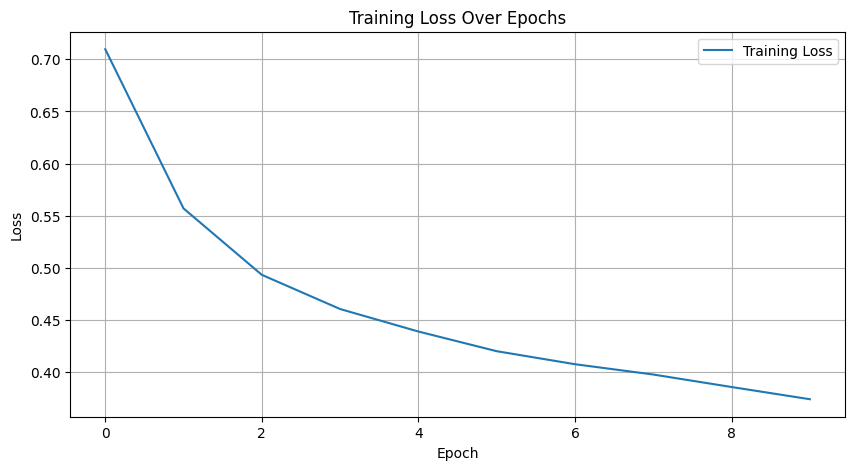

In [ ]:
# Plotting the training loss curve
plt.figure(figsize=(10, 5))
plt.plot(training_history['loss'], label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 6. Confusion Matrix

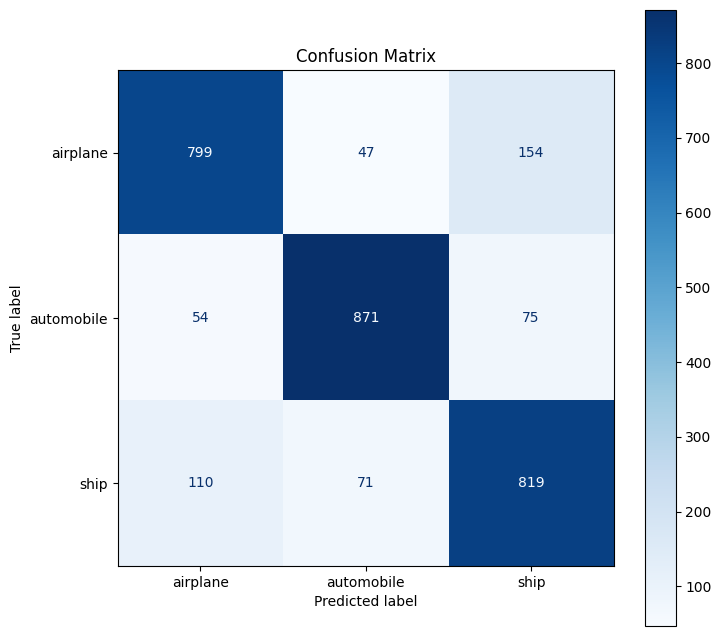

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def generate_confusion_matrix(model, test_loader, target_classes):
    model.eval()
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    cm = confusion_matrix(all_labels, all_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_classes)

    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title('Confusion Matrix')
    plt.show()

generate_confusion_matrix(model, test_loader, target_classes)

## 4. Evaluate the Classifier

Finally, we will evaluate the trained CNN classifier on the test images to assess its performance.

In [ ]:
# Evaluation loop
def evaluate_model(model, test_loader):
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Accuracy of the network on the {total} test images: {accuracy:.2f}%")

evaluate_model(model, test_loader)

Accuracy of the network on the 3000 test images: 82.97%
